In [20]:
import pandas as pd
import numpy as np

n = 1000000

# 1 Customer IDs
customer_id = np.arange(1, n+1)

# 2 Vehicle IDs
vehicle_id = ["V"+str(i) for i in range(1, n+1)]

# 3 Vehicle Value
vehicle_value = np.full(n, 100000)

# 4 Policy Tenure (20%,30%,40%,10%)
policy_tenure = np.random.choice([1,2,3,4], size=n, p=[0.2,0.3,0.4,0.1])

# 5 Premium
premium = policy_tenure * 100

# 6 Purchase Dates evenly across 2024
dates = pd.date_range("2024-01-01","2024-12-31")
purchase_dates = np.tile(dates, int(np.ceil(n/len(dates))))[:n]

# 7 Policy Start Date (+365 days)
start_dates = purchase_dates + pd.Timedelta(days=365)

# 8 Policy End Date
end_dates = start_dates + pd.to_timedelta(policy_tenure*365, unit="D")

# Create DataFrame
df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Vehicle_ID": vehicle_id,
    "Vehicle_Value": vehicle_value,
    "Policy_Tenure": policy_tenure,
    "Premium": premium,
    "Policy_Purchase_Date": purchase_dates,
    "Policy_Start_Date": start_dates,
    "Policy_End_Date": end_dates
})



# Saving dataset dataset
df.to_csv("policy_sales_data.csv", index=False)

In [21]:
df.tail()

,Customer_ID,Vehicle_ID,Vehicle_Value,Policy_Tenure,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date
999995,999996,V999996,100000,2,200,2024-03-24,2025-03-24,2027-03-24
999996,999997,V999997,100000,2,200,2024-03-25,2025-03-25,2027-03-25
999997,999998,V999998,100000,3,300,2024-03-26,2025-03-26,2028-03-25
999998,999999,V999999,100000,2,200,2024-03-27,2025-03-27,2027-03-27
999999,1000000,V1000000,100000,2,200,2024-03-28,2025-03-28,2027-03-28


In [22]:
import pandas as pd
import numpy as np

# Claim amount = 10% of vehicle value
claim_amount = 10000

# 1. CLAIMS IN 2025


# Select vehicles purchased on 7,14,21,28
eligible_2025 = df[df["Policy_Purchase_Date"].dt.day.isin([7,14,21,28])]

# Take 30% random sample
claims_2025 = eligible_2025.sample(frac=0.30, random_state=42)

claims_2025 = claims_2025[[
    "Customer_ID",
    "Vehicle_ID",
    "Policy_Start_Date"
]].copy()

claims_2025["Claim_Date"] = claims_2025["Policy_Start_Date"]
claims_2025["Claim_Amount"] = claim_amount
claims_2025["Claim_Type"] = 1


# 2. CLAIMS IN 2026

# Only 4-year tenure policies
eligible_2026 = df[df["Policy_Tenure"] == 4]

# Take 10% of them
claims_2026 = eligible_2026.sample(frac=0.10, random_state=42)

# Create 59 days (Jan1–Feb28)
claim_dates = pd.date_range("2026-01-01", "2026-02-28")

claims_2026 = claims_2026[[
    "Customer_ID",
    "Vehicle_ID"
]].copy()

# Distribute claim dates evenly
claims_2026["Claim_Date"] = np.tile(claim_dates,
                                    int(np.ceil(len(claims_2026)/len(claim_dates))))[:len(claims_2026)]

claims_2026["Claim_Amount"] = claim_amount
claims_2026["Claim_Type"] = 2

# 3. COMBINE CLAIMS

claims = pd.concat([claims_2025, claims_2026], ignore_index=True)

# Create Claim_ID
claims.insert(0, "Claim_ID", range(1, len(claims)+1))

print(claims.head())

# Save dataset
claims.to_csv("claims_data.csv", index=False)

   Claim_ID  Customer_ID Vehicle_ID Policy_Start_Date Claim_Date  \
0         1       294149    V294149        2025-09-07 2025-09-07   
1         2       157713    V157713        2025-11-28 2025-11-28   
2         3       228374    V228374        2025-12-21 2025-12-21   
3         4       615168    V615168        2025-10-14 2025-10-14   
4         5       281627    V281627        2025-06-21 2025-06-21   

   Claim_Amount  Claim_Type  
0         10000           1  
1         10000           1  
2         10000           1  
3         10000           1  
4         10000           1  


In [23]:
claims.head()

,Claim_ID,Customer_ID,Vehicle_ID,Policy_Start_Date,Claim_Date,Claim_Amount,Claim_Type
0,1,294149,V294149,2025-09-07,2025-09-07,10000,1
1,2,157713,V157713,2025-11-28,2025-11-28,10000,1
2,3,228374,V228374,2025-12-21,2025-12-21,10000,1
3,4,615168,V615168,2025-10-14,2025-10-14,10000,1
4,5,281627,V281627,2025-06-21,2025-06-21,10000,1


In [24]:
df.shape

(1000000, 8)

Q1) Calculate the total premium collected during the year 2024.


In [25]:
total_premium = df["Premium"].sum()
print("Total premium collected in 2024:-",total_premium)

Total premium collected in 2024:- 239949100


Q2) Calculate the total claim cost for each year (2025 and 2026) with a monthly breakdown

In [26]:
claims["Year"] = claims["Claim_Date"].dt.year
claims["Month"] = claims["Claim_Date"].dt.month

monthly_claims = claims.groupby(["Year","Month"])["Claim_Amount"].sum().reset_index()

print(monthly_claims)

    Year  Month  Claim_Amount
0   2025      1      32240000
1   2025      2      32490000
2   2025      3      32570000
3   2025      4      32450000
4   2025      5      32710000
5   2025      6      32310000
6   2025      7      33410000
7   2025      8      33330000
8   2025      9      33310000
9   2025     10      32150000
10  2025     11      33490000
11  2025     12      32980000
12  2026      1      52700000
13  2026      2      47520000


Q3 Calculate the claim cost to premium ratio for each policy tenure (1, 2, 3, and 4 years).

In [27]:
merged = claims.merge(df[["Customer_ID","Policy_Tenure","Premium"]], on="Customer_ID")

result = merged.groupby("Policy_Tenure").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

result["Claim_to_Premium_Ratio"] = result["Claim_Amount"] / result["Premium"]

print(result)

               Claim_Amount  Premium  Claim_to_Premium_Ratio
Policy_Tenure                                               
1                  78950000   789500              100.000000
2                 117050000  2341000               50.000000
3                 157950000  4738500               33.333333
4                 139710000  5588400               25.000000


Q4) Calculate the claim cost to premium ratio for each policy tenure (1, 2, 3, and 4 years).

In [28]:
df["Sale_Month"] = df["Policy_Purchase_Date"].dt.month

merged = claims.merge(df[["Customer_ID","Sale_Month","Premium"]], on="Customer_ID")

monthly_ratio = merged.groupby("Sale_Month").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

monthly_ratio["Ratio"] = monthly_ratio["Claim_Amount"] / monthly_ratio["Premium"]

print(monthly_ratio)

            Claim_Amount  Premium      Ratio
Sale_Month                                  
1               40720000  1105400  36.837344
2               40900000  1114100  36.711247
3               40980000  1114400  36.773151
4               40460000  1107000  36.549232
5               40770000  1114900  36.568302
6               40220000  1091500  36.848374
7               41560000  1137700  36.529841
8               42320000  1163100  36.385521
9               41400000  1112900  37.200108
10              40860000  1124300  36.342613
11              41960000  1141100  36.771536
12              41510000  1131000  36.702034


Q5) If every vehicle that has not yet made a claim eventually files exactly one claim during the
remaining policy tenure, estimate the total potential claim liability

In [29]:
claimed_customers = claims["Customer_ID"].unique()

not_claimed = df[~df["Customer_ID"].isin(claimed_customers)]

future_liability = len(not_claimed) * 10000

print(future_liability)

9510240000


Q6) Assume daily premium = Total Premium ÷ Total Policy Tenure Days. Based on this:
• Calculate the premium already earned by the company up to February 28, 2026.
• Estimate the premium expected to be earned monthly for the remaining policy period
(assume 46 months remaining).


In [30]:
df["Tenure_Days"] = df["Policy_Tenure"] * 365

In [31]:
df["Daily_Premium"] = df["Premium"] / df["Tenure_Days"]

• Calculate the premium already earned by the company up to February 28, 2026.

In [32]:
cutoff = pd.Timestamp("2026-02-28")

df["Earned_Days"] = (cutoff - df["Policy_Start_Date"]).dt.days
df["Earned_Days"] = df["Earned_Days"].clip(lower=0)

df["Earned_Premium"] = df["Earned_Days"] * df["Daily_Premium"]

earned_total = df["Earned_Premium"].sum()

print(earned_total)

66167734.79452054


• Estimate the premium expected to be earned monthly for the remaining policy period
(assume 46 months remaining).


In [33]:
remaining_premium = df["Premium"].sum() - earned_total

monthly_expected = remaining_premium / 46

print(monthly_expected)

3777855.76533651


BONUS QUESTIONS

Q1) Identify which policy tenure appears most profitable and explain why.


Loss Ratio = Total Claims / Total Premium

In [34]:
merged = claims.merge(df[["Customer_ID","Policy_Tenure","Premium"]], on="Customer_ID")

profitability = merged.groupby("Policy_Tenure").agg({
    "Claim_Amount":"sum",
    "Premium":"sum"
})

profitability["Loss_Ratio"] = profitability["Claim_Amount"] / profitability["Premium"]

print(profitability)

               Claim_Amount  Premium  Loss_Ratio
Policy_Tenure                                   
1                  78950000   789500  100.000000
2                 117050000  2341000   50.000000
3                 157950000  4738500   33.333333
4                 139710000  5588400   25.000000


3 years policies are the most profitable as they have the lowest loss ratio, meaning the company collects a lot more premium than the amount paid out as claims.


Q2) Build a simple dashboard or visualization showing claim trends by month.


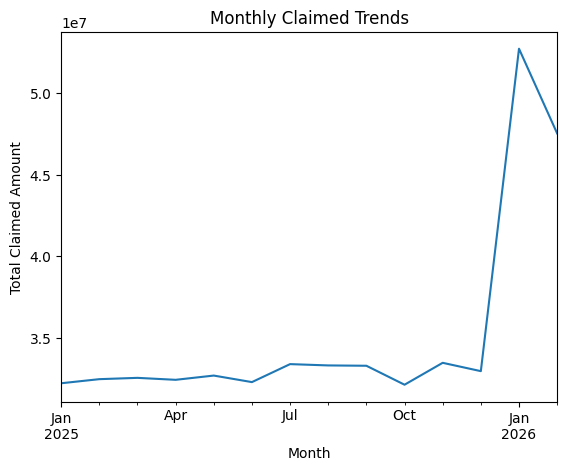

<Figure size 640x480 with 0 Axes>

In [36]:
import matplotlib.pyplot as plt

claims["Month"] = claims["Claim_Date"].dt.to_period("M")

monthly_claims = claims.groupby("Month")["Claim_Amount"].sum()

plt.figure()
monthly_claims.plot()
plt.xlabel("Month") 
plt.ylabel("Total Claimed Amount")
plt.title("Monthly Claimed Trends")
plt.show()
plt.savefig("Monthly claimed trends.png")

Q3) Estimate the loss ratio (Claims ÷ Premium) for the portfolio

Loss Ratio = Total Claims / Total Premium

In [ ]:
total_claims = claims["Claim_Amount"].sum()
total_premium = df["Premium"].sum()

loss_ratio = total_claims / total_premium

print(loss_ratio)


2.056731621493739


A loss ratio of 8% suggests the insurance portfolio is highly profitable because claims represent a small portion of total premium collected.

Q4) If claim frequency increases by 5% annually, estimate the impact on future profitability.


Future Claims = Current Claims × (1.05)^years

In [ ]:
years = 5
future_claims = total_claims * (1.05 ** years)

print(future_claims)

630215072.7468752


In [ ]:
future_loss_ratio = future_claims / total_premium

print(future_loss_ratio)

2.6249686475231884


If claim frequency rises by 5% each year, claims totals are subject to exponential growth, which can lead to higher loss ratios and lower profitability. Eventually, premium rates may need to change.